In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import sklearn
import pickle

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
def supervoxel_to_full_res(brain, cluster_labels):
    n_clusters = brain.shape[2]
    n_tp = brain.shape[1]
    brain_dims=[314,146]
    
    reformed_brain = []
    for z in range(brain.shape[0]):
        colored_by_betas = np.zeros((n_tp, brain_dims[0]*brain_dims[1]))
        for cluster_num in range(n_clusters):
            cluster_mask = cluster_labels[z,:]==cluster_num
#             print(cluster_indicies)
            colored_by_betas[:,cluster_mask] = brain[z,:,cluster_num,np.newaxis]
        colored_by_betas = colored_by_betas.reshape(n_tp,brain_dims[0],brain_dims[1])
        reformed_brain.append(colored_by_betas)
    return np.asarray(reformed_brain)
def dual_channel_remove_noise(arr_r, arr_g):
    z,xy,t=np.shape(arr_g)
    flat_red=arr_r.reshape(xy*z,t)
    flat_green=arr_g.reshape(xy*z,t)
    print(flat_green.shape)
    flat_sig=np.zeros_like(flat_green)
    for i in range(np.shape(flat_red)[0]):
        a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
        sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
        flat_sig[i,:]=sig
    return flat_sig.reshape(z,xy,t)
def make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_num):
    behave_dict = {}
    for behavior in behaviors:
        behave_dir = os.path.join(later_dir, behavior)
        behave_dict[behavior]=[]
        for file in os.listdir(behave_dir):
            if 'STA' in file and str(step_size) in file and event in file and f'_{ch_num}_' in file:
                STA_path=os.path.join(behave_dir, file)
                with h5py.File(STA_path, 'r') as sf:
                    brain = sf['data'][:]
                    brain[np.isnan(brain)] = 0
                    brain[np.isinf(brain)] = 4
                    brain = np.moveaxis(brain, 0, -1)
                    dims=np.shape(brain)
                    print(f'brain {file} shape: {dims}')
                    behave_dict[behavior]=brain
    return behave_dict

def make_supervox_dict(behave_dict, behaviors, n_clusters,cluster_labels):
    supervox_dict={}
    for behave in behaviors:
        supervox_dict[behave]=[]
        brain = behave_dict[behave]
        dims = np.shape(brain)
#         print(dims)
        for z in range(dims[-2]):
            neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
            signals = []
            for cluster_num in range(n_clusters):
                cluster_indicies = np.where(cluster_labels[z,:]==cluster_num)[0]
                mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
                signals.append(mean_signal)
            signals = np.asarray(signals)
            supervox_dict[behave].append(signals)
        supervox_dict[behave] = np.asarray(supervox_dict[behave])
        print(f'{behave} shape: {np.shape(supervox_dict[behave])}')
    return supervox_dict

In [3]:
### big STA supervox
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# behaviors = ['inc', 'dec', 'flat']

n_clusters=2000

step_size=100

event='best'

ch_g=2
ch_r=1

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [4]:
if event != None:
    event_times_path = os.path.join(home_path, f'{event}_event_times_split_dic.pkl')
else:
    event_times_path = os.path.join(home_path, 'event_times_split_dic.pkl')
with open(event_times_path, 'rb') as file:
    event_times_struct = pickle.load(file)
    f=list(event_times_struct.keys())[0]
    behaviors=list(event_times_struct[f].keys())
    print(f"Found behaviors: {behaviors}")

Found behaviors: ['inc', 'dec', 'flat']


In [5]:
behave_dict_g = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_g)
behave_dict_r = make_multi_behave_dict(behaviors,later_dir,step_size,event,ch_r)

brain STA_2_inc_100_best.h5 shape: (314, 146, 91, 24)
brain STA_2_dec_100_best.h5 shape: (314, 146, 91, 24)
brain STA_2_flat_100_best.h5 shape: (314, 146, 91, 24)
brain STA_1_inc_100_best.h5 shape: (314, 146, 91, 24)
brain STA_1_dec_100_best.h5 shape: (314, 146, 91, 24)
brain STA_1_flat_100_best.h5 shape: (314, 146, 91, 24)


In [6]:
behave_dict_g.keys()

dict_keys(['inc', 'dec', 'flat'])

In [7]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

# Turn both channel STA dicts into Supervoxels

In [8]:
%%time
supervox_dict_g=make_supervox_dict(behave_dict_g, behaviors, n_clusters,giant_cluster_labels)
supervox_dict_r=make_supervox_dict(behave_dict_r, behaviors, n_clusters,giant_cluster_labels)

inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
CPU times: user 36.1 s, sys: 139 ms, total: 36.3 s
Wall time: 36.3 s


# Remove noise using red channel regression

In [9]:
%%time
supervox_dict_total={}
for behave in behaviors:
    print(behave)
    arr_g=supervox_dict_g[behave]
    arr_r=supervox_dict_r[behave]
    total_behave=dual_channel_remove_noise(arr_r, arr_g)
    supervox_dict_total[behave]=total_behave

inc
(182000, 24)
dec
(182000, 24)
flat
(182000, 24)
CPU times: user 38.9 s, sys: 924 ms, total: 39.8 s
Wall time: 38.1 s


# Put the Supervoxs back into anatomical space

In [10]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
#     supervox_brain=lowpass_dict[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_dict_total[behave],-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=supervoxel_to_full_res(supervox_brain, giant_cluster_labels)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 36.7 s, sys: 880 ms, total: 37.5 s
Wall time: 37.5 s


In [11]:
fixed = brainsss.load_fda_meanbrain()
brain=full_res['inc']
# smoothed=gaussian_filter(brain, sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, brain, np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

In [12]:
atlas = brainsss.load_roi_atlas()
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, atlas)

In [13]:
def moving_average_2d(arr):
    num_bins=np.shape(arr)[-1]
    window_size=int(num_bins/5)
    # Apply uniform filter to compute the moving average
    return uniform_filter(arr, size=window_size, mode='constant')

def sort_rows_by_max_index(arr):
#     smoothed_row=moving_average_2d(arr)
    max_stim=[]
    max_not_stim=[]
    for i,row in enumerate(arr):
        loc=np.where(row==np.nanmax(row))[0][0]
    #     print(loc)
        if loc>6:
            max_stim.append(arr[i])
        else:
            max_not_stim.append(arr[i])
    max_stim=np.asarray(max_stim)
    max_not_stim=np.asarray(max_not_stim)

    max_indices_stim = np.nanargmax(max_stim, axis=1)
    sorted_order_stim = np.argsort(max_indices_stim)
    sorted_arr_stim = max_stim[sorted_order_stim,:]

    if max_not_stim.size>0:
        sorted_arr=np.vstack([sorted_arr_stim,max_not_stim])
    else:
        sorted_arr=np.vstack(sorted_arr_stim)

    return sorted_arr

In [14]:
%%time

total_vox_sorted={}
for behavior in full_res:
    STA=full_res[behavior]
    total_vox_sorted[behavior]={}
    for area in explosion_rois:
        for key in explosion_rois[area]['rois']:
            area_name=explosion_rois[area]['rois'][key]
            if '_R' in area_name or '_L' in area_name:
                total_area_name=area_name.split('_')
                if len(total_area_name)==3:
                    area_name=total_area_name[0]+'_'+total_area_name[1]
                else:
                    area_name=total_area_name[0]
            roi=key
            roi_mask=roi_masks[roi]
    #             print(np.shape(STA))
            masked_roi=[STA[...,i][roi_mask] for i in range(np.shape(STA)[-1])]
            masked_roi=np.transpose(masked_roi)
    #         roi_sort=sort_rows_by_max_index(masked_roi)
            try:
                np.append(total_vox_sorted[behavior][area_name], masked_roi)
            except KeyError:
                total_vox_sorted[behavior][area_name]=masked_roi

CPU times: user 6.21 s, sys: 128 ms, total: 6.33 s
Wall time: 6.33 s


In [15]:
np.shape(total_vox_sorted[behavior]['FB'])

(12480, 24)

In [16]:
roi_atlas = brainsss.load_roi_atlas()

In [17]:
explosion_rois = brainsss.load_explosion_groups()
all_rois = brainsss.unnest_roi_groups(explosion_rois)
roi_masks = brainsss.make_single_roi_masks(all_rois, roi_atlas)
roi_contours = brainsss.make_single_roi_contours(roi_masks, roi_atlas)

In [18]:
def extract_roi_signal_traces(roi_ids, roi_masks, warps, hemi, signal_type):
    t0 = time.time()
    roi_time_avgs = []
    for roi in roi_ids[hemi]:
        mask = roi_masks[roi]
        masked_data = warps[:,:,:,:]*mask[np.newaxis,:,:,:] #note z-flip
        if signal_type == 'max':
            roi_time_avg = np.max(masked_data,axis=(1,2,3))
        elif signal_type == 'mean':
            roi_time_avg = np.mean(masked_data,axis=(1,2,3))
        roi_time_avgs.append(roi_time_avg)
    print(time.time()-t0)
    return np.asarray(roi_time_avgs)

In [19]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

top_color=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7'])[::-1]
bottom=np.asarray(['#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
top_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'top_half_spect', top_color)
bottom_half_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'bottom_half_spect', bottom)

# Register the new colormap
plt.register_cmap(cmap=top_half_spect)
plt.register_cmap(cmap=bottom_half_spect)

In [64]:
be='inc'
t=2
brain=np.moveaxis(full_res[be],-1,0)
# brain=full_res[be]
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[t][:,:,::-1]
vmax = 0.1 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap=cmap_personal, diverging=True)#'hot')

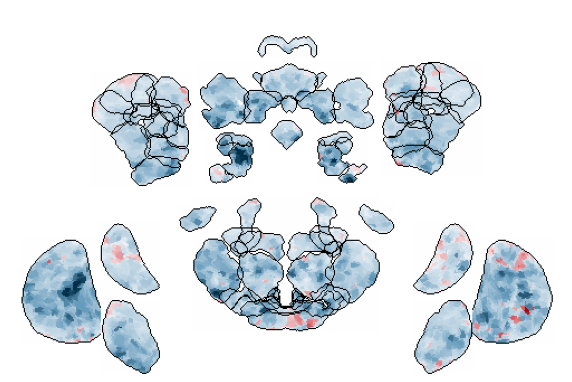

In [65]:
save_dir=os.path.join(later_dir,'figs')
plt.subplots(figsize=(10,10));
# plt.imshow(explosions[40][170:,:]) #this was made with cmap=hot
plt.imshow(explosion_map[170:,:]);
plt.axis('off');
# plt.savefig(os.path.join(save_dir,f'explode_{t}_{be}.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,f'explode_{t}_{be}_{event}.png'), dpi=300, bbox_inches='tight')

In [22]:
be='inc'
fixed = brainsss.load_fda_meanbrain()
brain=full_res[be]
# smoothed=gaussian_filter(full_res['total'], sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, behave_dict['total'], np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

In [23]:
masked.shape

(314, 146, 91, 24)

In [24]:
vox_traces=masked
# vox_traces_pre=masked[25]
# vox_traces_post=masked[75]
vox_traces_pre=masked[...,2]
vox_traces_post=masked[...,15]
print(vox_traces.shape)
# z,xy,t=vox_traces.shape
x,y,z,t=vox_traces.shape
# x,y,z,t=vox_traces.shape
flattened=vox_traces.reshape(x*y*z*t)
flattened_pre=vox_traces_pre.reshape(x*y*z)
flattened_post=vox_traces_post.reshape(x*y*z)
print(flattened.shape)

(314, 146, 91, 24)
(100123296,)


In [25]:
np.count_nonzero(~np.isnan(flattened_pre))

1586723

In [26]:
def mean_edges(flattened):
    mean_line=np.nanmean(flattened)
    std=np.nanstd(flattened)
    neg_edge=mean_line-std
    pos_edge=mean_line+std
    return mean_line, neg_edge, pos_edge

In [27]:
m,n,p=mean_edges(flattened)
mr,nr,pr=mean_edges(flattened_pre)
mo,no,po=mean_edges(flattened_post)

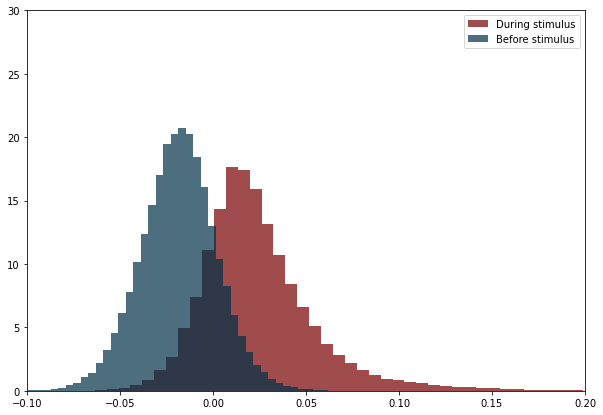

In [28]:
n_bins=100
plt.subplots(figsize=(10,7));
# plt.hist(flattened, bins=n_bins, density=True, color='k', label="Total");
plt.hist(flattened_post, bins=int(n_bins/2), density=True,color='#780000', alpha=0.7, label="During stimulus");
plt.hist(flattened_pre, bins=int(n_bins/2), density=True, color='#003049', alpha=0.7, label="Before stimulus");


# plt.axvline(m, ls='--', color='w')
# plt.axvline(n, ls='--', color='#efffa5')
# plt.axvline(p, ls='--', color='#efffa5')
plt.xlim((-0.1,0.2))
plt.ylim((0,30))
plt.legend()
# plt.savefig(os.path.join(save_dir,f'{be}_supervox_hist.png'), dpi=300, bbox_inches='tight')
# plt.savefig(os.path.join(save_dir,'supervox_hist.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [29]:
masked_dict={}
for behavior in behaviors:
    fixed = brainsss.load_fda_meanbrain()
    brain=full_res[behavior]
    # smoothed=gaussian_filter(full_res['total'], sigma=1.5)
    # masked=np.where(fixed.numpy()[...,None]>0.1, behave_dict['total'], np.nan)
    masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)
    masked_dict[behavior]=masked

In [30]:
print(np.shape(masked_dict['inc']))
masked_dict.keys()

(314, 146, 91, 24)


dict_keys(['inc', 'dec', 'flat'])

In [31]:
print(np.shape(supervox_dict_total['inc']))
supervox_dict_total.keys()

(91, 2000, 24)


dict_keys(['inc', 'dec', 'flat'])

In [32]:
flat_dict={}
for b in masked_dict:
    masked=supervox_dict_total[b]
    z,xy,t=masked.shape
    flatish=masked.reshape(-1,t)
    flat_dict[b]=flatish

In [33]:
print(np.shape(flat_dict['inc']))
flat_dict.keys()

(182000, 24)


dict_keys(['inc', 'dec', 'flat'])

In [34]:
colors={
    'inc': '#A2142F',
    'dec': '#727272',
    'flat': 'w'
}

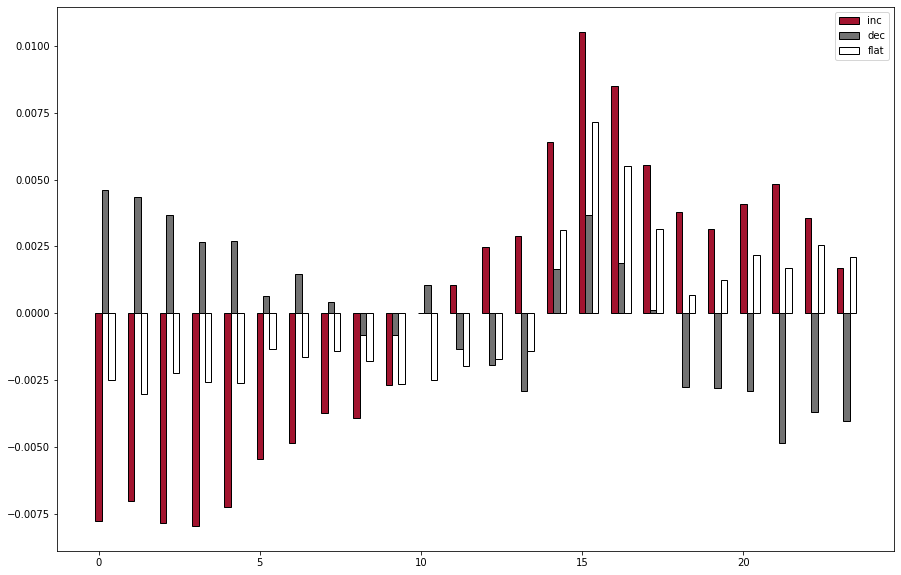

In [35]:
x = np.arange(len(flat_dict['inc'].T))  # the label locations
width = 0.20  # the width of the bars
multiplier = 0
fig, ax = plt.subplots(figsize=(15,10))
for b in flat_dict:
    offset = width * multiplier
    ax.bar(x+offset, np.nanmean(flat_dict[b],axis=0),width, color=colors[b], edgecolor='k', label=b)#yerr=np.nanmax(max_intes_time,axis=0), capsize=2
    multiplier+=1
# # ax.set_ylim((-0.02, 0.06))
# ax.set_xlim((-0.5, 24))
ax.legend();
# # ax.bar_label(rects, padding=3)
# # multiplier += 1
# ax.axvline(x=6, ls='--', color='k', lw=2);
# ax.axvline(x=16, ls='--', color='k', lw=2);
# plt.savefig(os.path.join(save_dir,f'behave_{step_size}_quant.png'), dpi=300, bbox_inches='tight')

In [87]:
one='inc'
two='dec'
diff=supervox_dict_total[one]-supervox_dict_total[two]
diff=np.moveaxis(diff,-1,0)
diff_fullres=supervoxel_to_full_res(diff, giant_cluster_labels)

In [88]:
diff_fullres.shape

(24, 91, 314, 146)

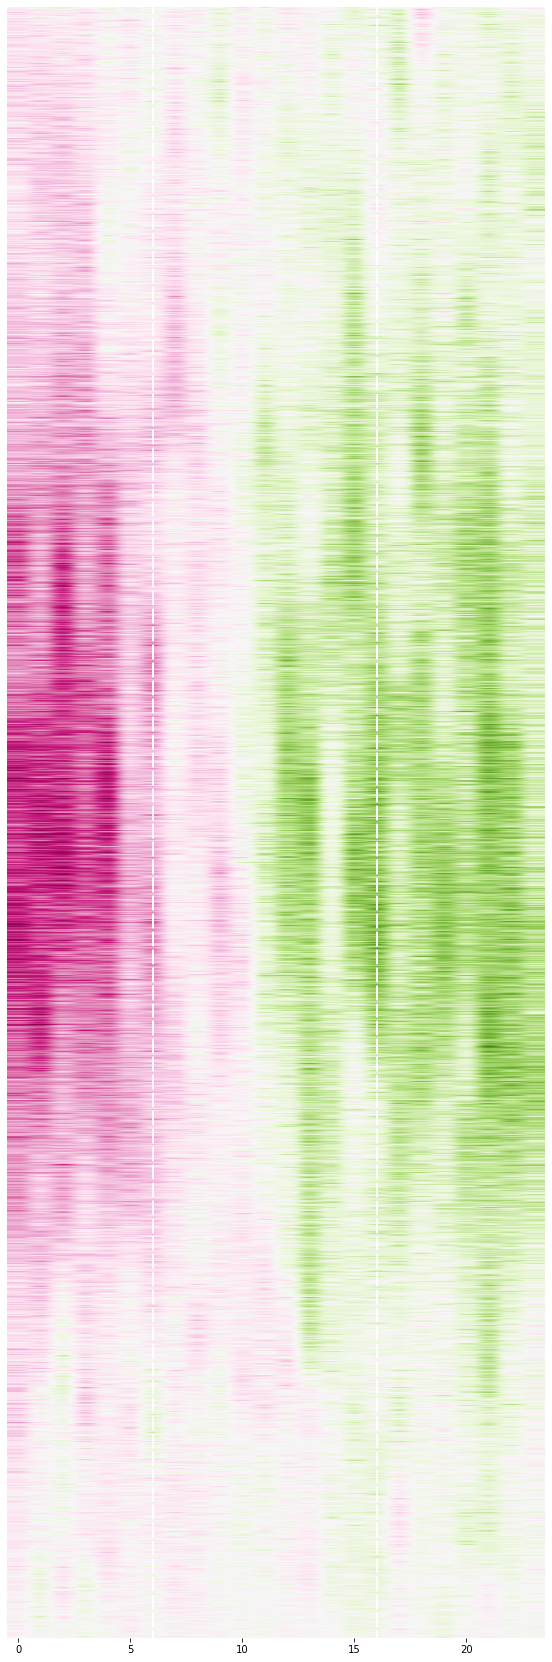

In [89]:
diff=supervox_dict_total[one]-supervox_dict_total[two]
# data=gaussian_filter(diff, sigma=1)
# data=supervox_dict[be]
vmax=0.03
vmin=-0.03
# norm = matplotlib.colors.Normalize(vmin=-vmax, vmax=vmax)
# final = norm(data)
# mycmap = matplotlib.cm.get_cmap('magma')
# final = mycmap(final)
num_areas=np.shape(diff)[0]
fig = plt.figure(figsize=(10,30))
gs = fig.add_gridspec(nrows=num_areas, ncols=1, hspace=0)
axs = gs.subplots(sharex='col', sharey=False)
for i in range(num_areas):
    img=axs[i].imshow(diff[i], cmap='PiYG', vmax=vmax, vmin=vmin)
    axs[i].set_yticks([])
    #     axs[i].set_xticks([])
    axs[i].set_aspect(0.0004)
    axs[i].axvline(x=6, ymin=0, ymax=1, ls='--', color='w', lw=2)
    axs[i].axvline(x=16, ymin=0, ymax=1, ls='--', color='w', lw=2)
#     axs[i].set_ylabel(f'z={i}', rotation=0, labelpad=20)
for ax in axs:
    ax.label_outer()
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
# plt.savefig(os.path.join(save_dir,f'supervox_heatmap_{one}_minus_{two}.png'), dpi=300, bbox_inches='tight')

In [ ]:
STA=np.moveaxis(diff_fullres,1,-1)
diff_sorted={}
for area in explosion_rois:
    for key in explosion_rois[area]['rois']:
        area_name=explosion_rois[area]['rois'][key]
        if '_R' in area_name or '_L' in area_name:
            total_area_name=area_name.split('_')
            if len(total_area_name)==3:
                area_name=total_area_name[0]+'_'+total_area_name[1]
            else:
                area_name=total_area_name[0]
        roi=key
        roi_mask=roi_masks[roi]
        masked_roi=[STA[i][roi_mask] for i in range(np.shape(STA)[0])]
        masked_roi=np.transpose(masked_roi)
#         roi_sort=sort_rows_by_max_index(masked_roi)
        try:
            np.append(diff_sorted[area_name], masked_roi)
        except KeyError:
            diff_sorted[area_name]=masked_roi

In [ ]:
anat_avgs={}
bbrain=diff_sorted
for anat in bbrain:
    n,t=np.shape(bbrain[anat])
    anat_avgs[anat] = (np.mean(bbrain[anat], axis=0))#/(np.std(bbrain[anat], axis=0)/np.sqrt(n)))

In [ ]:
anat_mean=np.nanmean(list(anat_avgs.values()))
anat_std=np.nanstd(list(anat_avgs.values()))

In [ ]:
np.shape(anat_avgs['FB'])

In [ ]:
# ##HOMEBREW ZSCORE
# anat_avgs_z={}
# bbrain=anat_avgs
# for anat in bbrain:
#     z = (bbrain[anat]-anat_mean)/anat_std
#     anat_avgs_z[anat]=z

In [ ]:
##BUILT IN ZSCORE
anat_avgs_z={}
bbrain=diff_sorted
for anat in bbrain:
    n,t=np.shape(bbrain[anat])
    mean = (np.mean(bbrain[anat], axis=0))
    z=scipy.stats.zscore(mean,axis=-1)
    anat_avgs_z[anat]=z

In [ ]:
np.shape(anat_avgs_z['FB'])

In [ ]:
avg_behave=anat_avgs_z
vmax=3

fig,axs = plt.subplots(figsize=(10,20),sharex='col', sharey=False)
diff_img=axs.imshow(avg_behave.values(), vmax=3, cmap='PiYG')
axs.label_outer()
axs.set_aspect(1)
axs.axvline(x=5, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.axvline(x=15, ymin=0, ymax=1, ls='--', color='k', lw=2)
axs.set_yticks(np.arange(len(list(avg_behave.keys()))))
axs.set_yticklabels(list(avg_behave.keys()))
axs.set_xticks([])
# fig.colorbar(diff_img)

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{one}_minus_{two}.png'), dpi=300, bbox_inches='tight')

# plt.savefig(os.path.join(save_dir,f'avg_anat_heatmap_{one}_minus_{two}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)
        
plt.show()

In [ ]:
t=17
brain=np.moveaxis(diff_fullres,1,-1)
input_canvas = np.ones((500,500,3)) #+.5 #.5 for diverging
data_to_plot = brain[t][:,:,::-1]
vmax = 0.08 #this was 0.5 for STA <------------
explosion_map = brainsss.place_roi_groups_on_canvas(explosion_rois,
                                                    roi_masks,
                                                    roi_contours,
                                                    data_to_plot,
                                                    input_canvas,
                                                    vmax=vmax,
                                                    cmap='PiYG', diverging=True)#'hot')

In [ ]:
save_dir=os.path.join(later_dir,'figs')
fig,axs=plt.subplots(figsize=(10,10))
im=axs.imshow(explosion_map[170:,:])
axs.axis('off')
# fig.colorbar(im)